# NeuralMag Cube Surface Relaxation

A clean single-case workflow:

1. define an inner cube edge, a surface layer thickness, and one random seed;
2. build one uniform cell grid that contains the inner cube plus the surface layer;
3. relax the magnetization with NeuralMag's top-level `minimise` helper;
4. project the relaxed cube face-on and with the tilted Libertem-holo projector.

`inner_edge_length_nm` is the original cube edge. `surface_thickness_nm` is added on every face, so the simulated outer edge is `inner_edge_length_nm + 2 * surface_thickness_nm`.


In [54]:
from __future__ import annotations

import os
import sys
import time
from pathlib import Path

os.environ.setdefault("JAX_ENABLE_X64", "1")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.25")

from jax import config as jax_config

jax_config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import unxt as u

cwd = Path.cwd().resolve()
repo_root = next((path for path in (cwd, *cwd.parents) if (path / "pyproject.toml").exists()), cwd)
for path in (repo_root / "src", repo_root / "vendor" / "neuralmag"):
    if path.exists() and str(path) not in sys.path:
        sys.path.insert(0, str(path))

import neuralmag as nm
from libertem_holo.base.mbir import MU_0, forward_phase_from_density_and_magnetization
from libertem_holo.base.mbir.forward import forward_model_3d_tilted, project_3d, project_3d_tilted

nm.config.dtype = "float64"
plt.rcParams["image.origin"] = "lower"
np.set_printoptions(precision=5, suppress=True)

print(f"Repo root: {repo_root}")
print(f"NeuralMag backend: {getattr(nm.config.backend, 'name', nm.config.backend)}")


2026-04-29 15:46:11 NeuralMag:INFO [NeuralMag] Set default dtype to 'float64'.


Repo root: /Users/landers/LiberTEM-holo
NeuralMag backend: jax


## Parameters


In [55]:
inner_edge_length_nm = 80.0
cell_size_nm = 1.0
surface_thickness_nm = 10.0
random_seed = 21

ms_core_a_per_m = 480e3
ms_surface_a_per_m = 100e3
aex_j_per_m = 1e-11
kc_core_j_per_m3 = -1.3e4
demag_p = 3

minimise_tol = 1e2
minimise_max_iter = 50_000

# Set this to False for the plain top-level nm.minimise call.
# Set it to True to preserve BB history while printing diagnostics every chunk.
debug_minimise_in_chunks = False
minimise_chunk_iter = 1_000

phase_padding_px = 32
tilt_rotation_deg = 45.0
tilt_deg = 45.0


def cells_for_length(length_nm, cell_size_nm, name):
    cells = int(round(float(length_nm) / float(cell_size_nm)))
    if not np.isclose(cells * cell_size_nm, length_nm):
        raise ValueError(f"{name} must be an integer multiple of cell_size_nm.")
    return cells


core_cells = cells_for_length(inner_edge_length_nm, cell_size_nm, "inner_edge_length_nm")
surface_cells = cells_for_length(surface_thickness_nm, cell_size_nm, "surface_thickness_nm")
n = core_cells + 2 * surface_cells
outer_edge_length_nm = n * cell_size_nm

shape_xyz = (n, n, n)
mesh_step_m = (cell_size_nm * 1e-9,) * 3
print(f"Inner cube: {inner_edge_length_nm:g} nm = {core_cells} cells")
print(f"Surface layer: {surface_thickness_nm:g} nm per face = {surface_cells} cells")
print(f"Simulation grid: {shape_xyz}, outer edge {outer_edge_length_nm:g} nm")


Inner cube: 80 nm = 80 cells
Surface layer: 10 nm per face = 10 cells
Simulation grid: (100, 100, 100), outer edge 100 nm


## Cube And Initial Magnetization


In [56]:
def cell_centers_nm(shape_xyz, spacing_nm):
    axes = [
        (np.arange(size, dtype=np.float64) + 0.5) * spacing_nm - (size * spacing_nm / 2.0)
        for size in shape_xyz
    ]
    return np.meshgrid(*axes, indexing="ij")


def cube_masks(shape_xyz, spacing_nm, inner_edge_nm):
    xx, yy, zz = cell_centers_nm(shape_xyz, spacing_nm)
    max_abs_nm = np.maximum.reduce([np.abs(xx), np.abs(yy), np.abs(zz)])
    core = max_abs_nm <= (float(inner_edge_nm) / 2.0)
    surface = ~core
    return core, surface


def normalize_vectors(values):
    values = np.asarray(values, dtype=np.float64)
    norm = np.linalg.norm(values, axis=-1, keepdims=True)
    return values / np.where(norm > 0.0, norm, 1.0)


def initial_magnetization(core, surface, spacing_nm, seed):
    xx, yy, zz = cell_centers_nm(core.shape, spacing_nm)
    phi = np.arctan2(yy, xx)

    vortex = np.zeros(core.shape + (3,), dtype=np.float64)
    vortex[..., 0] = -np.sin(phi)
    vortex[..., 1] = np.cos(phi)
    vortex[..., 2] = 0.15 * np.tanh(zz / (0.2 * inner_edge_length_nm))
    vortex = normalize_vectors(vortex)

    rng = np.random.default_rng(seed)
    random_surface = normalize_vectors(rng.normal(size=vortex.shape))
    return normalize_vectors(core[..., None] * vortex + surface[..., None] * random_surface)


core, surface = cube_masks(shape_xyz, cell_size_nm, inner_edge_length_nm)
ms_field = np.where(core, ms_core_a_per_m, ms_surface_a_per_m).astype(np.float64)
kc_field = np.where(core, kc_core_j_per_m3, 0.0).astype(np.float64)
m0_cell = initial_magnetization(core, surface, cell_size_nm, random_seed)

print(f"Core cells: {int(core.sum()):,}")
print(f"Surface cells: {int(surface.sum()):,}")
print(f"Expected core cells: {core_cells ** 3:,}")
print(f"Mean initial m: {m0_cell.reshape(-1, 3).mean(axis=0)}")


Core cells: 512,000
Surface cells: 488,000
Expected core cells: 512,000
Mean initial m: [-0.00019  0.00084 -0.00109]


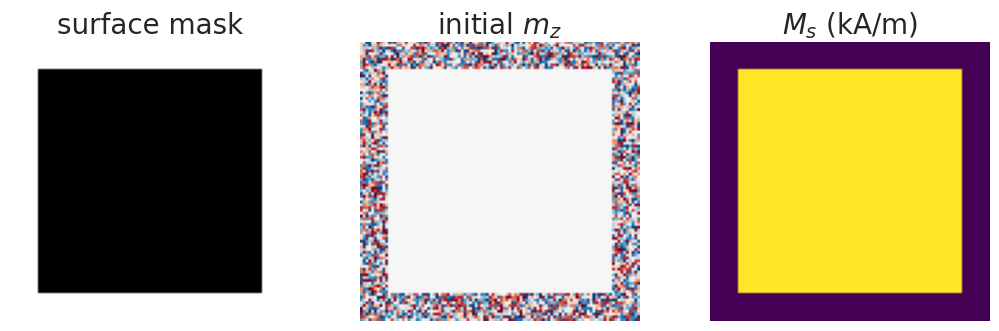

In [57]:
mid = n // 2
fig, axs = plt.subplots(1, 3, figsize=(10.5, 3.2), constrained_layout=True)

axs[0].imshow(surface[:, :, mid].T, cmap="gray")
axs[0].set_title("surface mask")
axs[1].imshow(m0_cell[:, :, mid, 2].T, cmap="RdBu_r", vmin=-1, vmax=1)
axs[1].set_title("initial $m_z$")
axs[2].imshow(ms_field[:, :, mid].T / 1e3, cmap="viridis")
axs[2].set_title("$M_s$ (kA/m)")

for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()


## NeuralMag Relaxation


In [58]:
def constant_vector_cell_function(state, vector_xyz):
    values = np.broadcast_to(np.asarray(vector_xyz, dtype=np.float64), shape_xyz + (3,)).copy()
    return nm.VectorCellFunction(state, tensor=state.tensor(values, dtype=state.dtype))


def cell_vectors_to_node_function(state, values_xyz):
    cell = nm.VectorCellFunction(state, tensor=state.tensor(values_xyz, dtype=state.dtype))
    return nm.VectorFunction(state, tensor=state.tensor(normalize_vectors(np.asarray(cell.to_node().tensor)), dtype=state.dtype))


def build_state(m_cell):
    state = nm.State(nm.Mesh(shape_xyz, mesh_step_m))
    state.t = state.tensor(0.0)
    state.rho = nm.CellFunction(state).fill(1.0)
    state.material.Ms = nm.CellFunction(state, tensor=state.tensor(ms_field, dtype=state.dtype))
    state.material.A = nm.CellFunction(state).fill(aex_j_per_m)
    state.material.Kc = nm.CellFunction(state, tensor=state.tensor(kc_field, dtype=state.dtype))

    axis_111 = np.array([1.0, 1.0, 1.0], dtype=np.float64)
    axis_111 /= np.linalg.norm(axis_111)
    axis_1m10 = np.array([1.0, -1.0, 0.0], dtype=np.float64)
    axis_1m10 -= np.dot(axis_1m10, axis_111) * axis_111
    axis_1m10 /= np.linalg.norm(axis_1m10)
    axis_11m2 = np.cross(axis_111, axis_1m10)

    state.material.Kc_axis1 = constant_vector_cell_function(state, axis_111)
    state.material.Kc_axis2 = constant_vector_cell_function(state, axis_1m10)
    state.material.Kc_axis3 = constant_vector_cell_function(state, axis_11m2)
    state.m = cell_vectors_to_node_function(state, m_cell)

    nm.ExchangeField().register(state, "exchange")
    nm.DemagField(p=demag_p).register(state, "demag")
    nm.CubicAnisotropyField().register(state, "cubic")
    nm.TotalField("exchange", "demag", "cubic").register(state)
    return state


def unit_node_projection(m_node):
    norm = jnp.linalg.norm(m_node, axis=-1, keepdims=True)
    return m_node / jnp.maximum(norm, jnp.finfo(m_node.dtype).eps)


def minimizer_options():
    return dict(
        method="alternating",
        update="cayley",
        projection=unit_node_projection,
        tau_min=1e-18,
        tau_max=1e-4,
        tol=minimise_tol,
        max_iter=minimise_max_iter,
    )


def build_minimizer(state):
    return nm.EnergyMinimizer(state, **minimizer_options())


def relaxed_cell_magnetization(state):
    return normalize_vectors(np.asarray(state.m.to_cell().tensor))


def max_g_diagnostics(state, solver=None):
    solver = build_minimizer(state) if solver is None else solver
    h, g, max_g = solver._compute_current_direction(state.m.tensor)
    h = np.asarray(jax.device_get(h))
    g = np.asarray(jax.device_get(g))
    g_norm = np.linalg.norm(g, axis=-1)
    idx = tuple(int(i) for i in np.unravel_index(np.argmax(g_norm), g_norm.shape))

    ms_node = np.asarray(state.material.Ms.to_node().tensor)
    kc_node = np.asarray(state.material.Kc.to_node().tensor)
    ms_here = float(ms_node[idx])
    region = "core" if abs(ms_here - ms_core_a_per_m) < abs(ms_here - ms_surface_a_per_m) else "surface"

    return {
        "max_g": float(np.asarray(max_g)),
        "node_index": idx,
        "region": region,
        "Ms_A_per_m": ms_here,
        "Kc_J_per_m3": float(kc_node[idx]),
        "m": np.asarray(state.m.tensor)[idx].copy(),
        "h_A_per_m": h[idx].copy(),
        "g_A_per_m": g[idx].copy(),
        "g_norm": g_norm,
    }


def run_chunked_minimise(state):
    solver = build_minimizer(state)
    history = []
    started = time.perf_counter()

    while solver.n_iter < minimise_max_iter:
        target_iter = min(solver.n_iter + int(minimise_chunk_iter), int(minimise_max_iter))
        _, info = solver.minimize(tol=minimise_tol, max_iter=target_iter, return_info=True)
        diag = max_g_diagnostics(state, solver)
        row = {
            "n_iter": int(solver.n_iter),
            "energy_j": float(np.asarray(state.E)),
            "converged": bool(np.asarray(info["converged"])),
            "max_g": float(np.asarray(info["max_g"])),
            "hotspot": diag,
            "elapsed_s": time.perf_counter() - started,
        }
        history.append(row)
        print(
            f"{row['n_iter']:>7,} iter | max_g={row['max_g']:.3e} | "
            f"E={row['energy_j']:.6e} J | hotspot={diag['node_index']} ({diag['region']})"
        )
        if row["converged"]:
            break
        if target_iter == minimise_max_iter:
            break

    return bool(history[-1]["converged"]), history[-1], history


In [59]:
state = build_state(m0_cell)


converged, info = nm.minimise(
    state,
    **minimizer_options(),
    return_info=True,
)
minimise_history = [{
    "n_iter": int(np.asarray(info["n_iter"])),
    "energy_j": float(np.asarray(state.E)),
    "converged": bool(np.asarray(info["converged"])),
    "max_g": float(np.asarray(info["max_g"])),
    "hotspot": max_g_diagnostics(state),
}]
m_cell = relaxed_cell_magnetization(state)
final_hotspot = minimise_history[-1]["hotspot"]

print(f"converged: {converged}")
print(f"iterations: {int(np.asarray(info['n_iter'])):,}")
print(f"max |m x (m x h)|: {float(np.asarray(info['max_g'])):.3g}")
print(f"energy: {float(np.asarray(state.E)):.6e} J")


2026-04-29 15:46:11 NeuralMag:INFO [Mesh] 3D, 100 x 100 x 100 (size = 1e-09 x 1e-09 x 1e-09)
2026-04-29 15:46:11 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-29 15:46:11 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-04-29 15:46:11 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-29 15:46:11 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-29 15:46:11 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-29 15:46:13 NeuralMag:INFO [CubicAnisotropyField] Register state methods (field: 'h_cubic', energy: 'E_cubic', energy density: 'e_cubic')
2026-04-29 15:46:13 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-29 15:46:18 NeuralMag:INFO [EnergyMinimizerJAX] Minimization started, initial energy E = 1.05823e-14 

converged: True
iterations: 15,270
max |m x (m x h)|: 99.3
energy: 1.976353e-17 J


## Magnetization And Phase Projections


In [ ]:
def xyz_to_zyx(values):
    axes = (2, 1, 0) if values.ndim == 3 else (2, 1, 0, 3)
    return np.transpose(np.asarray(values), axes)


def pad_xyz(values, pad_px):
    values = np.asarray(values)
    pad_width = [(pad_px, pad_px)] * 3 + ([(0, 0)] if values.ndim == 4 else [])
    return np.pad(values, pad_width, mode="constant")


def density_and_induction_zyx(m_cell, ms_a_per_m, pad_px=0):
    m_cell = normalize_vectors(m_cell)
    ms_a_per_m = np.asarray(ms_a_per_m, dtype=np.float64)
    if ms_a_per_m.shape != m_cell.shape[:3]:
        raise ValueError(f"Ms shape {ms_a_per_m.shape} must match magnetization shape {m_cell.shape[:3]}.")

    support_xyz = np.linalg.norm(m_cell, axis=-1) > 1e-8
    induction_xyz = m_cell * (float(MU_0.value) * ms_a_per_m)[..., None]
    return xyz_to_zyx(pad_xyz(support_xyz.astype(np.float64), pad_px)), xyz_to_zyx(pad_xyz(induction_xyz, pad_px))


def phase_axes_nm(image_yx):
    y_size, x_size = image_yx.shape
    x_nm = (np.arange(x_size) - (x_size - 1) / 2.0) * cell_size_nm
    y_nm = (np.arange(y_size) - (y_size - 1) / 2.0) * cell_size_nm
    return x_nm, y_nm


def phase_from_magnetization(m_cell, ms_a_per_m, pad_px=phase_padding_px):
    rho_zyx, induction_zyx = density_and_induction_zyx(m_cell, ms_a_per_m, pad_px=pad_px)
    phase = forward_phase_from_density_and_magnetization(
        rho=rho_zyx,
        magnetization_3d=induction_zyx,
        pixel_size=u.Quantity(cell_size_nm, "nm"),
        projection_step_size=u.Quantity(cell_size_nm, "nm"),
        axis="z",
        geometry="disc",
    )
    return np.asarray(jax.device_get(phase), dtype=np.float64)


def tilted_phase_from_magnetization(m_cell, ms_a_per_m):
    _, induction_zyx = density_and_induction_zyx(m_cell, ms_a_per_m, pad_px=phase_padding_px)
    phase_q = forward_model_3d_tilted(
        u.Quantity(jnp.asarray(induction_zyx), ""),
        pixel_size=u.Quantity(cell_size_nm, "nm"),
        rotation=np.deg2rad(tilt_rotation_deg),
        tilt=np.deg2rad(tilt_deg),
        geometry="disc",
    )
    return np.asarray(jax.device_get(phase_q.value), dtype=np.float64)


def plot_m_components_and_phase(m_cell, phase_yx, title, *, extra_phase_yx=None, extra_phase_title=None):
    m_cell = normalize_vectors(m_cell)
    mid = m_cell.shape[2] // 2
    panels = [
        (m_cell[:, :, mid, 0].T, "$m_x$", "RdBu_r", -1.0, 1.0),
        (m_cell[:, :, mid, 1].T, "$m_y$", "RdBu_r", -1.0, 1.0),
        (m_cell[:, :, mid, 2].T, "$m_z$", "RdBu_r", -1.0, 1.0),
    ]
    phase_lim = max(float(np.max(np.abs(phase_yx))), 1e-12)
    panels.append((phase_yx, "phase", "RdBu_r", -phase_lim, phase_lim))
    if extra_phase_yx is not None:
        extra_lim = max(float(np.max(np.abs(extra_phase_yx))), 1e-12)
        panels.append((extra_phase_yx, extra_phase_title or "extra phase", "RdBu_r", -extra_lim, extra_lim))

    fig, axs = plt.subplots(1, len(panels), figsize=(3.4 * len(panels), 3.5), constrained_layout=True)
    axs = np.atleast_1d(axs)
    for ax, (image, panel_title, cmap, vmin, vmax) in zip(axs, panels):
        im = ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(panel_title)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    plt.show()

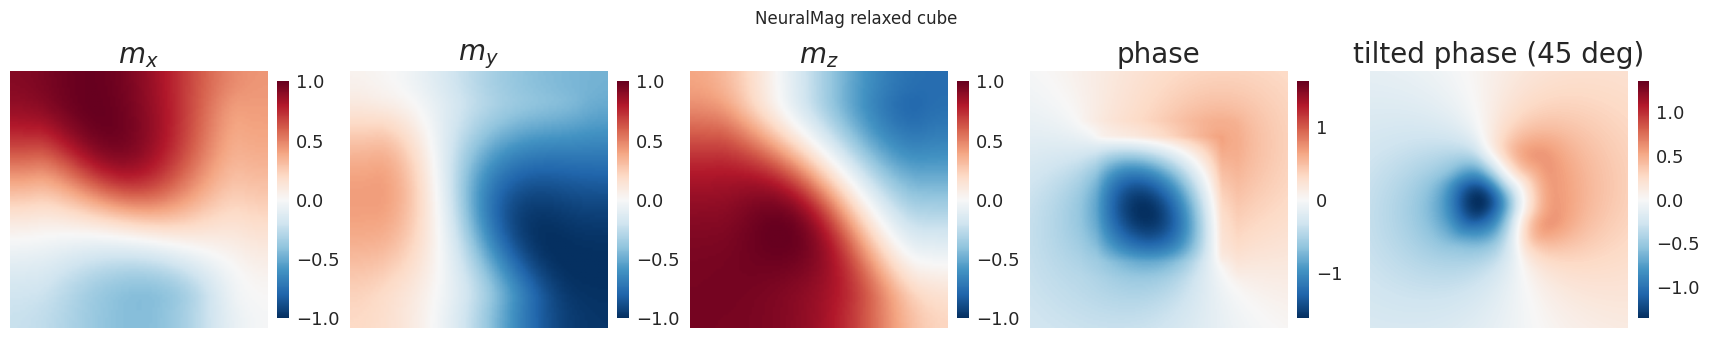

In [61]:
face_phase = phase_from_magnetization(m_cell, ms_field, pad_px=phase_padding_px)
tilted_phase = tilted_phase_from_magnetization(m_cell, ms_field)

plot_m_components_and_phase(
    m_cell,
    face_phase,
    "NeuralMag relaxed cube",
    extra_phase_yx=tilted_phase,
    extra_phase_title=f"tilted phase ({tilt_deg:g} deg)",
)
